In [44]:
import pandas as pd
import missingno
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

pd.set_option("display.max_columns", None)

In [2]:
main_color = 'steelblue'
dark_color = 'navy'
accent_color = 'orange'

In [3]:
df = pd.read_parquet('Data/meteo_cleaned_new_features.parquet')

In [4]:
df_model_PM25 = df.drop(columns=['CO2', 'NO', 'NO2', 'PN[5-100nm]', 'SO2',  'eBC2.5','NOx'])

In [6]:
# Create rolling 1- and 24-hour averages
# use mean for temperature, humidity
# for others use median - spiky

# keep track of the rolling average features, so we can see how correlated they are with each other later
# then decide which ones to keep
avg_col = []


# 1h mean
for col in ['T', 'T_Trockner', 'wind_y', 'wind_x']:
    df_model_PM25[col+'_1h_mean'] = df_model_PM25[col].rolling(window=6, min_periods=1).mean()
    avg_col = avg_col + [col+'_1h_mean']

# 1h meadian
for col in ['Hr', 'Hr_Trockner', 'WD']:
    df_model_PM25[col+'_1h_med'] = df_model_PM25[col].rolling(window=6, min_periods=1).median()
    avg_col = avg_col + [col+'_1h_med']

# 1h max
for col in ['RainDur', 'StrGlo', 'wind_dir_y', 'WVv', ]:
    df_model_PM25[col+'_1h_max'] = df_model_PM25[col].rolling(window=6, min_periods=1).max()
    avg_col = avg_col + [col+'_1h_max']

# 24h mean
for col in ['Hr_Trockner', 'RainDur', 'T_Trockner', 'WD', 'WVv', 'wind_x',  'wind_dir_x',  'wind_y']:
    df_model_PM25[col+'_24h_mean'] = df_model_PM25[col].rolling(window=144, min_periods=1).mean()
    avg_col = avg_col + [col+'_24h_mean']

# 24h median
for col in ['StrGlo', 'T', 'wind_dir_y']:
    df_model_PM25[col+'_24h_med'] = df_model_PM25[col].rolling(window=144, min_periods=1).median()
    avg_col = avg_col + [col+'_24h_med']


print(avg_col)


['T_1h_mean', 'T_Trockner_1h_mean', 'wind_y_1h_mean', 'wind_x_1h_mean', 'Hr_1h_med', 'Hr_Trockner_1h_med', 'WD_1h_med', 'RainDur_1h_max', 'StrGlo_1h_max', 'wind_dir_y_1h_max', 'WVv_1h_max', 'Hr_Trockner_24h_mean', 'RainDur_24h_mean', 'T_Trockner_24h_mean', 'WD_24h_mean', 'WVv_24h_mean', 'wind_x_24h_mean', 'wind_dir_x_24h_mean', 'wind_y_24h_mean', 'StrGlo_24h_med', 'T_24h_med', 'wind_dir_y_24h_med']


In [7]:
df_model_PM25.select_dtypes(include='object').columns


Index(['day', 'season'], dtype='object')

In [8]:
df_model_PM25 = pd.get_dummies(df_model_PM25, columns=['season'], drop_first=False)

In [9]:
df_model_PM25['dayofyear'] = pd.to_datetime(df_model_PM25['day']).dt.dayofyear
df_model_PM25 = df_model_PM25.drop(columns='day')
display(df_model_PM25.columns)

Index(['Hr', 'Hr_Trockner', 'PM2.5', 'RainDur', 'StrGlo', 'T', 'T_Trockner',
       'WD', 'WVv', 'year', 'hour', 'day_of_week', 'month',
       'PM2.5_gap_too_long', 'PM2.5_was_interpolated', 'NOx_gap_too_long',
       'NOx_was_interpolated', 'NO_gap_too_long', 'NO_was_interpolated',
       'NO2_gap_too_long', 'NO2_was_interpolated', 'eBC2.5_gap_too_long',
       'eBC2.5_was_interpolated', 'PN[5-100nm]_gap_too_long',
       'PN[5-100nm]_was_interpolated', 'Hr_gap_too_long',
       'Hr_was_interpolated', 'Hr_Trockner_gap_too_long',
       'Hr_Trockner_was_interpolated', 'RainDur_gap_too_long',
       'RainDur_was_interpolated', 'StrGlo_gap_too_long',
       'StrGlo_was_interpolated', 'T_gap_too_long', 'T_was_interpolated',
       'T_Trockner_gap_too_long', 'T_Trockner_was_interpolated',
       'WD_gap_too_long', 'WD_was_interpolated', 'WVv_gap_too_long',
       'WVv_was_interpolated', 'is_weekend', 'is_night', 'wind_dir_x',
       'wind_dir_y', 'wind_x', 'wind_y', 'wind_sector_N', 'wind

In [10]:
df_model_PM25.dtypes.value_counts()

float64    35
int64      30
bool       12
int32       5
Name: count, dtype: int64

In [14]:
path_df_model_PM25 = 'Data/df_model_PM2.5_cleaned.parquet'

In [11]:
df_model_PM25.to_parquet('Data/df_model_PM2.5_cleaned.parquet')

In [12]:
target_col = 'PM2.5'

# Baseline - training only on weather data

## Train a random forest model

MAE: 2.5077214556777894
RMSE: 3.368472163114951
R²: 0.2984571361151146


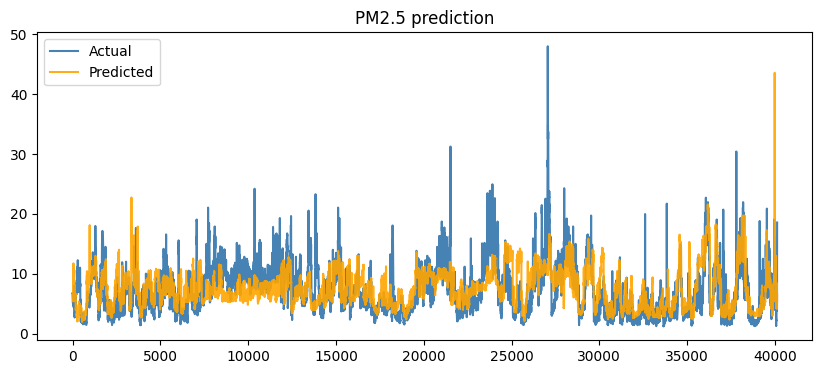

In [47]:
# for the random forest, we have to remove missing values
df_model_PM25 = pd.read_parquet(path_df_model_PM25)
df_model_PM25 = df_model_PM25.dropna()

from sklearn.model_selection import train_test_split

X = df_model_PM25.drop(columns=target_col)
y = df_model_PM25[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False  # no shuffle for time series
)

from sklearn.ensemble import RandomForestRegressor

model_RF = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_RF.fit(X_train, y_train)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model_RF.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))


plt.figure(figsize=(10,4))
plt.plot(y_test.values, label='Actual', color=main_color)
plt.plot(y_pred, label='Predicted', color=accent_color, alpha=0.9)
plt.legend()
plt.title(f'{target_col} prediction')
plt.show()

In [48]:
joblib.dump(model_RF, 'models/RF_PM2.5_weather_only.pkl')

['models/RF_PM2.5_weather_only.pkl']

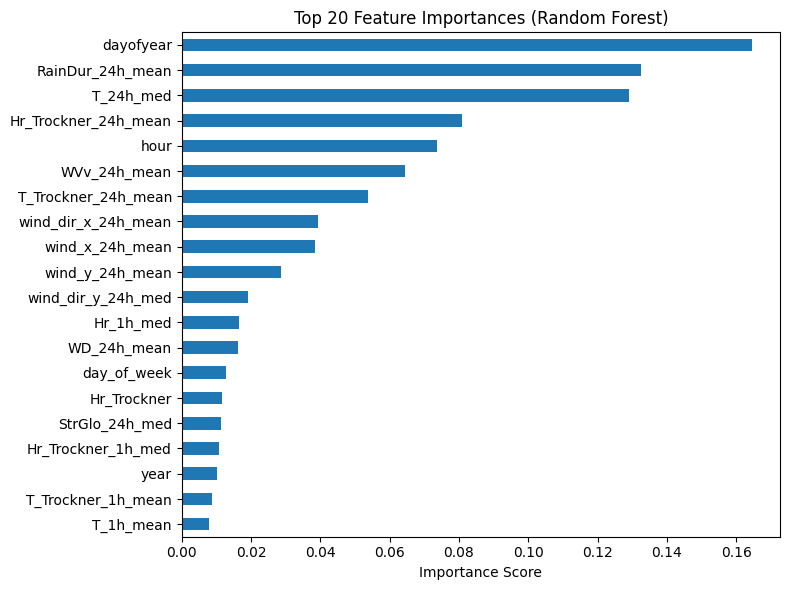

In [49]:
# Create a Series of importances with feature names
importances = pd.Series(model_RF.feature_importances_, index=X_train.columns)

# Sort and show top 20
top_features = importances.sort_values(ascending=False).head(20)

# Plot
plt.figure(figsize=(8, 6))
top_features.plot(kind='barh')
plt.gca().invert_yaxis()  # highest at the top
plt.title("Top 20 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()


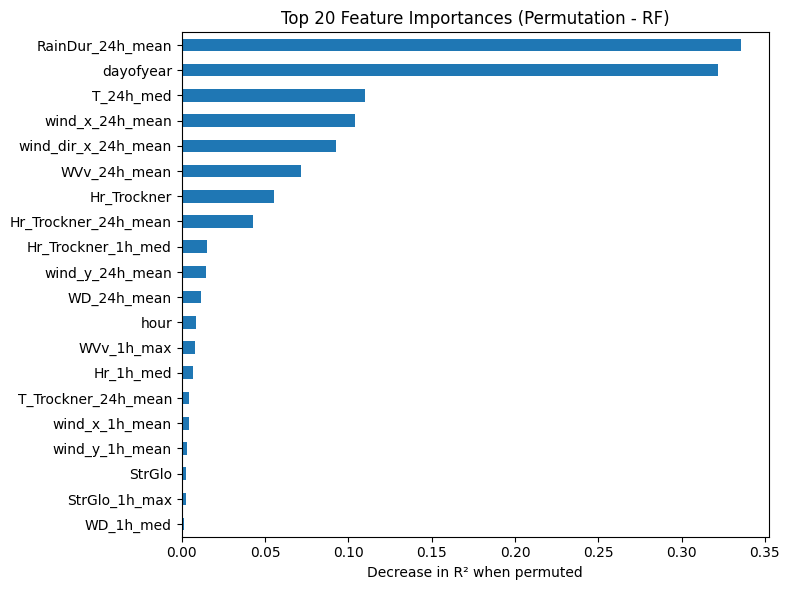

In [50]:
from sklearn.inspection import permutation_importance

result = permutation_importance(model_RF, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

import pandas as pd
import matplotlib.pyplot as plt

# Create a Series from the importances
perm_importances = pd.Series(result.importances_mean, index=X_test.columns)

# Plot top 20
top_perm = perm_importances.sort_values(ascending=False).head(20)
plt.figure(figsize=(8, 6))
top_perm.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances (Permutation - RF)")
plt.xlabel("Decrease in R² when permuted")
plt.tight_layout()
plt.show()



In [51]:
import json
import pandas as pd

# Save metrics
metrics = {
    "r2": r2_score(y_test, y_pred),
    "rmse": np.sqrt(mean_squared_error(y_test, y_pred)),
    "mae": mean_absolute_error(y_test, y_pred)
}
model_type ='RF'
with open(f"results/{model_type}_{target_col}_weather_only_metrics.json", "w") as f:
    json.dump(metrics, f)

# Save predicted vs actual
# pred_df = pd.DataFrame({
#     "y_true": y_test.values,
#     "y_pred": y_pred
# })
# pred_df.to_parquet(f"results/{model_type}_{target_col}_weather_only_predictions.parquet")
pd.DataFrame({'y_test': y_test}).to_parquet(f'results/{model_type}_{target_col}_weather_only_y_test.parquet')
pd.DataFrame({'y_true': y_test.values, 'y_pred': y_pred}).to_parquet(f'results/{model_type}_{target_col}_weather_only_predictions_.parquet')


# Save top features
top_features_df = top_features.to_frame()
top_features_df.to_parquet(f"results/{model_type}_{target_col}_weather_only_top_features.parquet")

top_perm = perm_importances.to_frame()
top_perm.to_parquet(f"results/{model_type}_{target_col}_weather_only_top_perm.parquet")



## Gradient boost - HGBR

In [52]:
df_model_PM25 = pd.read_parquet(path_df_model_PM25)

In [53]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Drop missing values just for target (not features — model handles those)
df_model_PM25 = df_model_PM25.dropna(subset=[target_col])

X = df_model_PM25.drop(columns=target_col)
y = df_model_PM25[target_col]

# Train-test split (no shuffle because of time series)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Create and train the model
model_HGBR = HistGradientBoostingRegressor(max_iter=100, random_state=42)
model_HGBR.fit(X_train, y_train)

# Predict
y_pred = model_HGBR.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")


MAE: 2.379
RMSE: 3.272
R²: 0.337


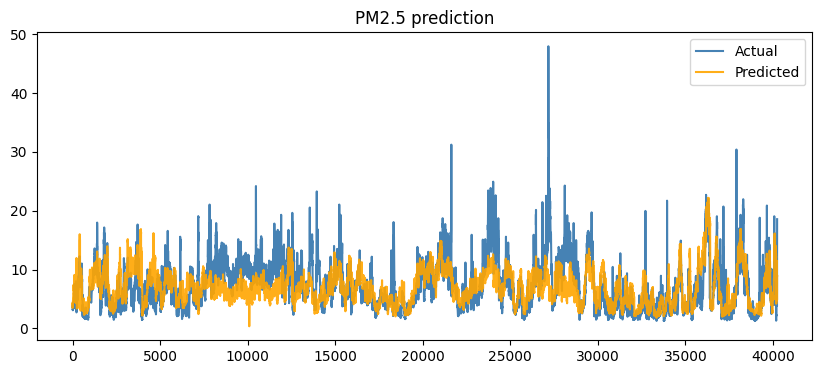

In [54]:
plt.figure(figsize=(10,4))
plt.plot(y_test.values, label='Actual', color=main_color)
plt.plot(y_pred, label='Predicted', color=accent_color, alpha=0.9)
plt.legend()
plt.title(f'{target_col} prediction')
plt.show()

In [55]:
joblib.dump(model_HGBR, 'models/HGBR_PM2.5_weather_only.pkl')


['models/HGBR_PM2.5_weather_only.pkl']

how much worse the model performs when each feature is shuffled.



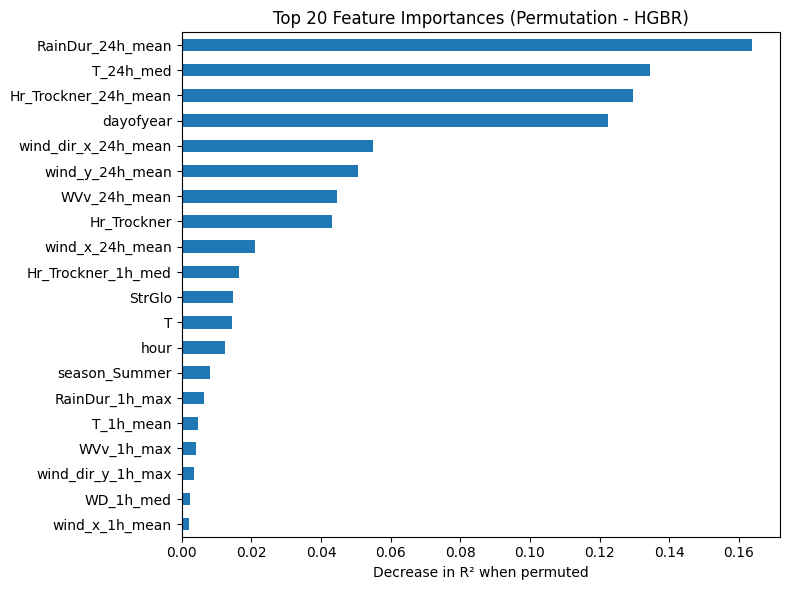

In [56]:
from sklearn.inspection import permutation_importance

result = permutation_importance(model_HGBR, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

import pandas as pd
import matplotlib.pyplot as plt

# Create a Series from the importances
perm_importances = pd.Series(result.importances_mean, index=X_test.columns)

# Plot top 20
top_perm = perm_importances.sort_values(ascending=False).head(20)
plt.figure(figsize=(8, 6))
top_perm.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances (Permutation - HGBR)")
plt.xlabel("Decrease in R² when permuted")
plt.tight_layout()
plt.show()



In [57]:
import json
import pandas as pd

# Save metrics
metrics = {
    "r2": r2_score(y_test, y_pred),
    "rmse": np.sqrt(mean_squared_error(y_test, y_pred)),
    "mae": mean_absolute_error(y_test, y_pred)
}
model_type ='HGBR'
with open(f"results/{model_type}_{target_col}_weather_only_metrics.json", "w") as f:
    json.dump(metrics, f)

# Save predicted vs actual
# pred_df = pd.DataFrame({
#     "y_true": y_test.values,
#     "y_pred": y_pred
# })
# pred_df.to_parquet(f"results/{model_type}_{target_col}_weather_only_predictions.parquet")
pd.DataFrame({'y_test': y_test}).to_parquet(f'results/{model_type}_{target_col}_weather_only_y_test.parquet')
pd.DataFrame({'y_true': y_test.values, 'y_pred': y_pred}).to_parquet(f'results/{model_type}_{target_col}_weather_only_predictions_.parquet')


# # Save top features
# top_features_df = top_features.to_frame()
# top_features_df.to_parquet(f"results/{model_type}_{target_col}_weather_only_top_features.parquet")

top_perm = perm_importances.to_frame()
top_perm.to_parquet(f"results/{model_type}_{target_col}_weather_only_top_perm.parquet")



**Note**: NOx can be better predicted by weather variables

## Using lagged features

In [22]:

df_model_PM25 = pd.read_parquet(path_df_model_PM25)

In [24]:
df_model_PM25['PM2.5_lag_1'] = df_model_PM25['PM2.5'].shift(1)
df_model_PM25['PM2.5_lag_6'] = df_model_PM25['PM2.5'].shift(6)
df_model_PM25['PM2.5_lag_12'] = df_model_PM25['PM2.5'].shift(12)
df_model_PM25['PM2.5_roll_1h'] = df_model_PM25['PM2.5'].shift(1).rolling(window=6, min_periods=1).mean()


In [25]:
df_model_PM25 = df_model_PM25.dropna(subset=['PM2.5', 'PM2.5_lag_1', 'PM2.5_lag_6', 'PM2.5_lag_12', 'PM2.5_roll_1h'])


In [26]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Drop missing values just for target (not features — model handles those)
df_model_PM25 = df_model_PM25.dropna(subset=[target_col])

X = df_model_PM25.drop(columns=target_col)
y = df_model_PM25[target_col]

# Train-test split (no shuffle because of time series)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Create and train the model
model_HGBR_lagged = HistGradientBoostingRegressor(max_iter=100, random_state=42)
model_HGBR_lagged.fit(X_train, y_train)

# Predict
y_pred = model_HGBR_lagged.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")


MAE: 0.281
RMSE: 0.584
R²: 0.979


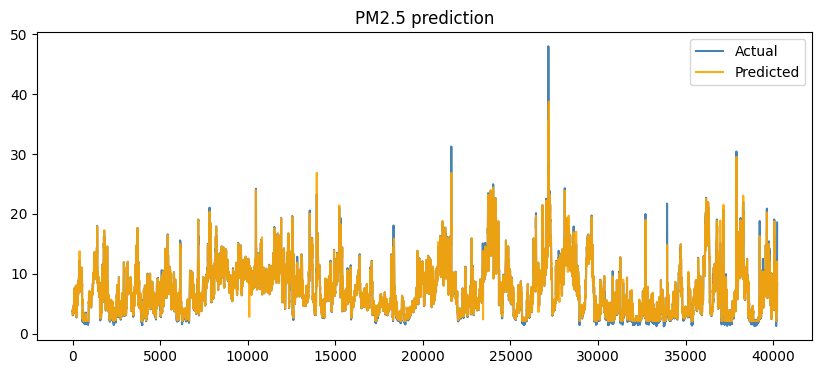

In [27]:
plt.figure(figsize=(10,4))
plt.plot(y_test.values, label='Actual', color=main_color)
plt.plot(y_pred, label='Predicted', color=accent_color, alpha=0.9)
plt.legend()
plt.title(f'{target_col} prediction')
plt.show()

how much worse the model performs when each feature is shuffled.



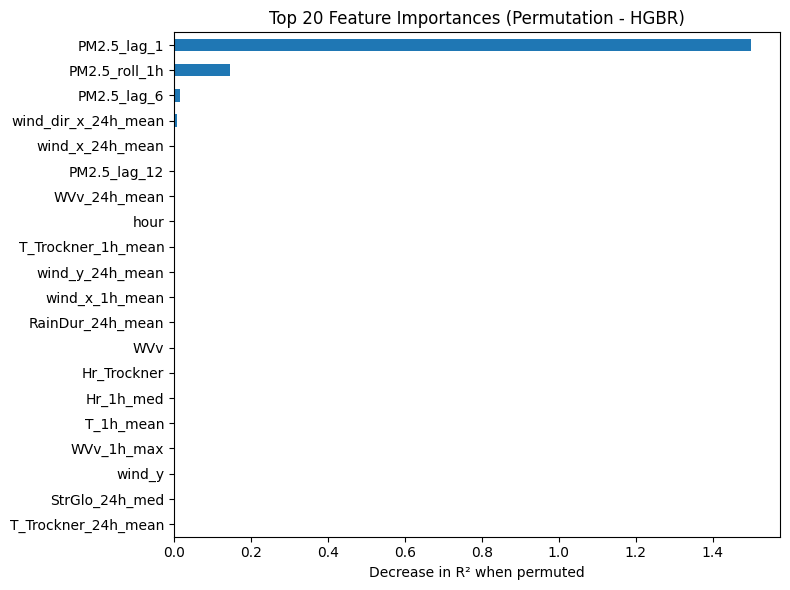

In [28]:
from sklearn.inspection import permutation_importance

result = permutation_importance(model_HGBR_lagged, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

import pandas as pd
import matplotlib.pyplot as plt

# Create a Series from the importances
perm_importances = pd.Series(result.importances_mean, index=X_test.columns)

# Plot top 20
top_perm = perm_importances.sort_values(ascending=False).head(20)
plt.figure(figsize=(8, 6))
top_perm.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances (Permutation - HGBR)")
plt.xlabel("Decrease in R² when permuted")
plt.tight_layout()
plt.show()



## Lagged model, with only NOx data

In [29]:

df_model_PM25 = pd.read_parquet(path_df_model_PM25)

In [30]:
df_model_PM25['PM2.5_lag_1'] = df_model_PM25['PM2.5'].shift(1)
df_model_PM25['PM2.5_lag_6'] = df_model_PM25['PM2.5'].shift(6)
df_model_PM25['PM2.5_lag_12'] = df_model_PM25['PM2.5'].shift(12)
df_model_PM25['PM2.5_roll_1h'] = df_model_PM25['PM2.5'].shift(1).rolling(window=6, min_periods=1).mean()


In [31]:
df_model_PM25 = df_model_PM25.dropna(subset=['PM2.5', 'PM2.5_lag_1', 'PM2.5_lag_6', 'PM2.5_lag_12', 'PM2.5_roll_1h'])


In [34]:
df_model_PM25_lagged_only = df_model_PM25[['PM2.5', 'PM2.5_lag_1', 'PM2.5_lag_6', 'PM2.5_lag_12', 'PM2.5_roll_1h']]

In [35]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Drop missing values just for target (not features — model handles those)
df_model_PM25_lagged_only = df_model_PM25_lagged_only.dropna(subset=[target_col])

X = df_model_PM25_lagged_only.drop(columns=target_col)
y = df_model_PM25_lagged_only[target_col]

# Train-test split (no shuffle because of time series)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Create and train the model
model_HGBR_lagged_only = HistGradientBoostingRegressor(max_iter=100, random_state=42)
model_HGBR_lagged_only.fit(X_train, y_train)

# Predict
y_pred = model_HGBR_lagged_only.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")


MAE: 0.257
RMSE: 0.619
R²: 0.976


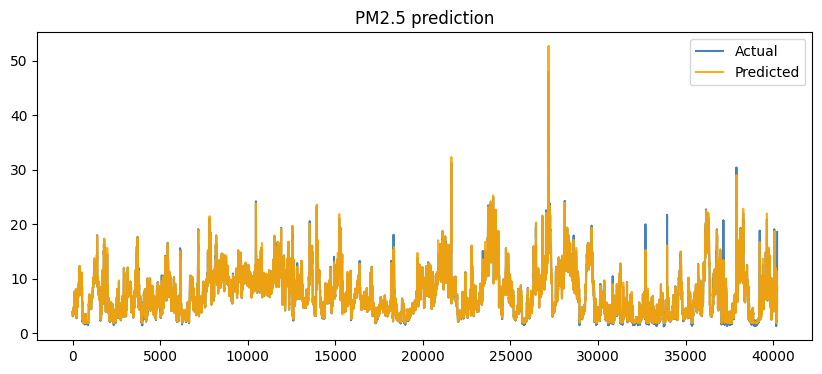

In [36]:
plt.figure(figsize=(10,4))
plt.plot(y_test.values, label='Actual', color=main_color)
plt.plot(y_pred, label='Predicted', color=accent_color, alpha=0.9)
plt.legend()
plt.title(f'{target_col} prediction')
plt.show()

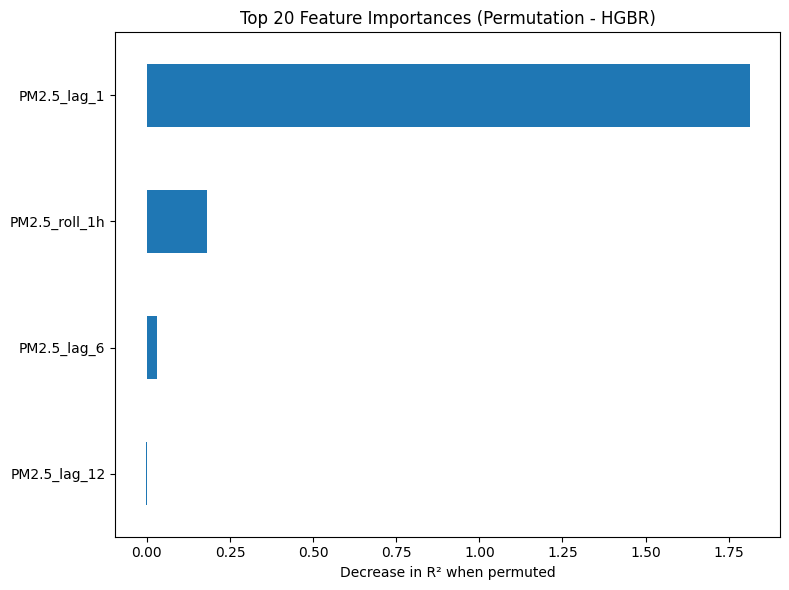

In [37]:
from sklearn.inspection import permutation_importance

result = permutation_importance(model_HGBR_lagged_only, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

import pandas as pd
import matplotlib.pyplot as plt

# Create a Series from the importances
perm_importances = pd.Series(result.importances_mean, index=X_test.columns)

# Plot top 20
top_perm = perm_importances.sort_values(ascending=False).head(20)
plt.figure(figsize=(8, 6))
top_perm.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances (Permutation - HGBR)")
plt.xlabel("Decrease in R² when permuted")
plt.tight_layout()
plt.show()

